In [1]:
%load_ext autoreload
%autoreload 2
%cd /opt/tiger/samantha

/mnt/bd/janne-research-sm/samantha


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import os
import pandas as pd
from glob import glob
from tqdm import tqdm
from samantha.utils.hdfs_helper import hdfs_ls

In [3]:
from recipes.research.audio_codec.scripts.compile import get_commit_log_folder

2024-07-09 12:57:04.507777: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-07-09 12:57:04.556944: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-09 12:57:05.297129: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [4]:
# hdfs_folder = get_commit_log_folder("75266bd")  # rq 32gpu
hdfs_folder = get_commit_log_folder("1898c17")  # rq 8gpu
hdfs_folder

2024-07-09 12:57:07,333 - samantha.utils.hdfs_helper - INFO - Listing HDFS directory hdfs://harunava/home/byte_data_seed_us/hdd_va/speech/data/js/logs/*/*/1898c17/*/*


'hdfs://harunava/home/byte_data_seed_us/hdd_va/speech/data/js/logs/mel_codec/default/1898c17/2024-07-09/01-02-36'

## Node URLs

In [5]:
from typing import List

BASE_URL = "hdfs://harunava/home/byte_data_seed_us/hdd_va/speech/data_store/BigMusic/"

def get_data_urls(data_urls: List[str]):

    dfs = []
    for url in tqdm(data_urls):   
        global_rank = int(os.path.splitext(os.path.basename(url))[0].split("_")[-1])

        df = pd.read_csv(
            url,
            sep=";",
            names=["dataloader_idx", "urls"]
        )
        df["global_rank"] = global_rank
        dfs.append(df)
    dfs = pd.concat(dfs)
    return dfs


def get_data_monitor(monitor_urls: List[str]):

    dfs = []
    for fp in tqdm(monitor_urls):
        dfs.append(
            pd.read_csv(
            fp,
            sep=";",
            names=["epoch", "step", "batch_idx", "idx", "local_rank", "global_rank", "node_rank", "id", "shard_url", "data_type"]
        ))
    dfs = pd.concat(dfs)
    dfs["shard_url"] = dfs["shard_url"].str.replace(BASE_URL, "")
    dfs["shard_url_base"] = dfs["shard_url"].str.split("/").str[0]
    return dfs

In [6]:
# data_urls = hdfs_ls(f"{hdfs_folder}/monitor/data_urls_*")

data_urls = glob("monitor/data_urls_*")
data_urls = get_data_urls(data_urls)

100%|██████████| 8/8 [00:00<00:00, 616.99it/s]


In [7]:
import json
data_urls["urls"] = data_urls["urls"].apply(lambda r: json.loads(r.replace("\'", "\"")))
data_urls["index"] = data_urls["urls"].apply(lambda r: r["index"])
data_urls["data"] = data_urls["urls"].apply(lambda r: r["data"])

In [8]:
# data_urls.groupby("global_rank").head(8).head(50)["index"].tolist()

## Data Monitor

In [9]:
# monitor_urls = hdfs_ls(f"{hdfs_folder}/monitor/data_monitor_*")

monitor_urls = glob("monitor/data_monitor_*")
monitor = get_data_monitor(monitor_urls)

100%|██████████| 8/8 [00:00<00:00, 830.12it/s]


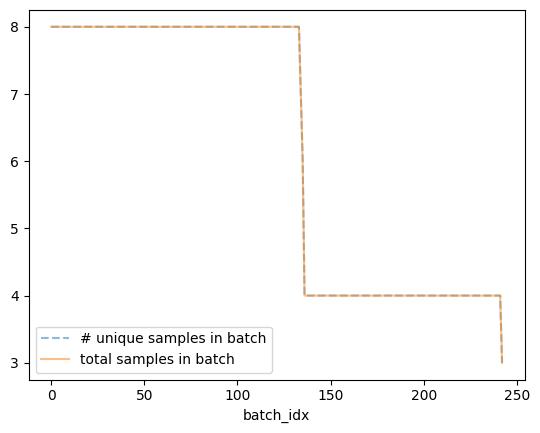

In [10]:
import matplotlib.pyplot as plt
monitor.groupby("batch_idx")["id"].nunique().plot(label="# unique samples in batch", alpha=0.5, linestyle="--")
monitor.groupby("batch_idx")["id"].count().plot(label="total samples in batch", alpha=0.5)
plt.legend()
plt.show()

In [11]:
monitor["id"].unique().shape

(1512,)

<Axes: xlabel='batch_idx'>

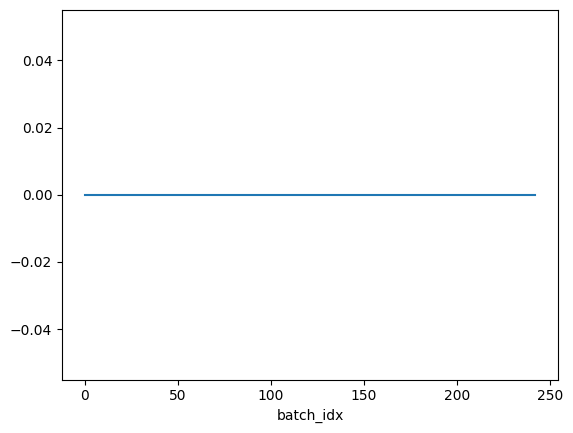

In [12]:

duplicates_per_batch = (monitor.groupby("batch_idx")["id"].count() - monitor.groupby("batch_idx")["id"].nunique())
# (duplicates_per_batch / dfs.groupby("batch_idx")["id"].count()).plot()
duplicates_per_batch.plot()

In [13]:
## shows if any duplicate id's exist within the same batch:
duplicates = monitor[monitor.duplicated(subset=["batch_idx", "id", "epoch"], keep=False)].sort_values(by=["id"])
duplicates

,epoch,step,batch_idx,idx,local_rank,global_rank,node_rank,id,shard_url,data_type,shard_url_base


# Epochs

In [14]:
DATASET_SIZE = 2160769 # PlaylistV5

batch_size = monitor["idx"].max() + 1
n_ranks = monitor["global_rank"].max() + 1
global_step = monitor["step"].max()

global_batch_size = batch_size * n_ranks

n_datapoints_seen = global_batch_size * global_step

print("Global batch size:", global_batch_size)
print("Ranks:", n_ranks)
print("Global step:", global_step)
print("Datapoints seen (theoretical):", n_datapoints_seen)
print("Monitor:", len(monitor))

n_epochs = n_datapoints_seen / DATASET_SIZE
print("Epochs:", n_epochs)

Global batch size: 8
Ranks: 8
Global step: 242
Datapoints seen (theoretical): 1936
Monitor: 1512
Epochs: 0.0008959773117811297


1512 1512


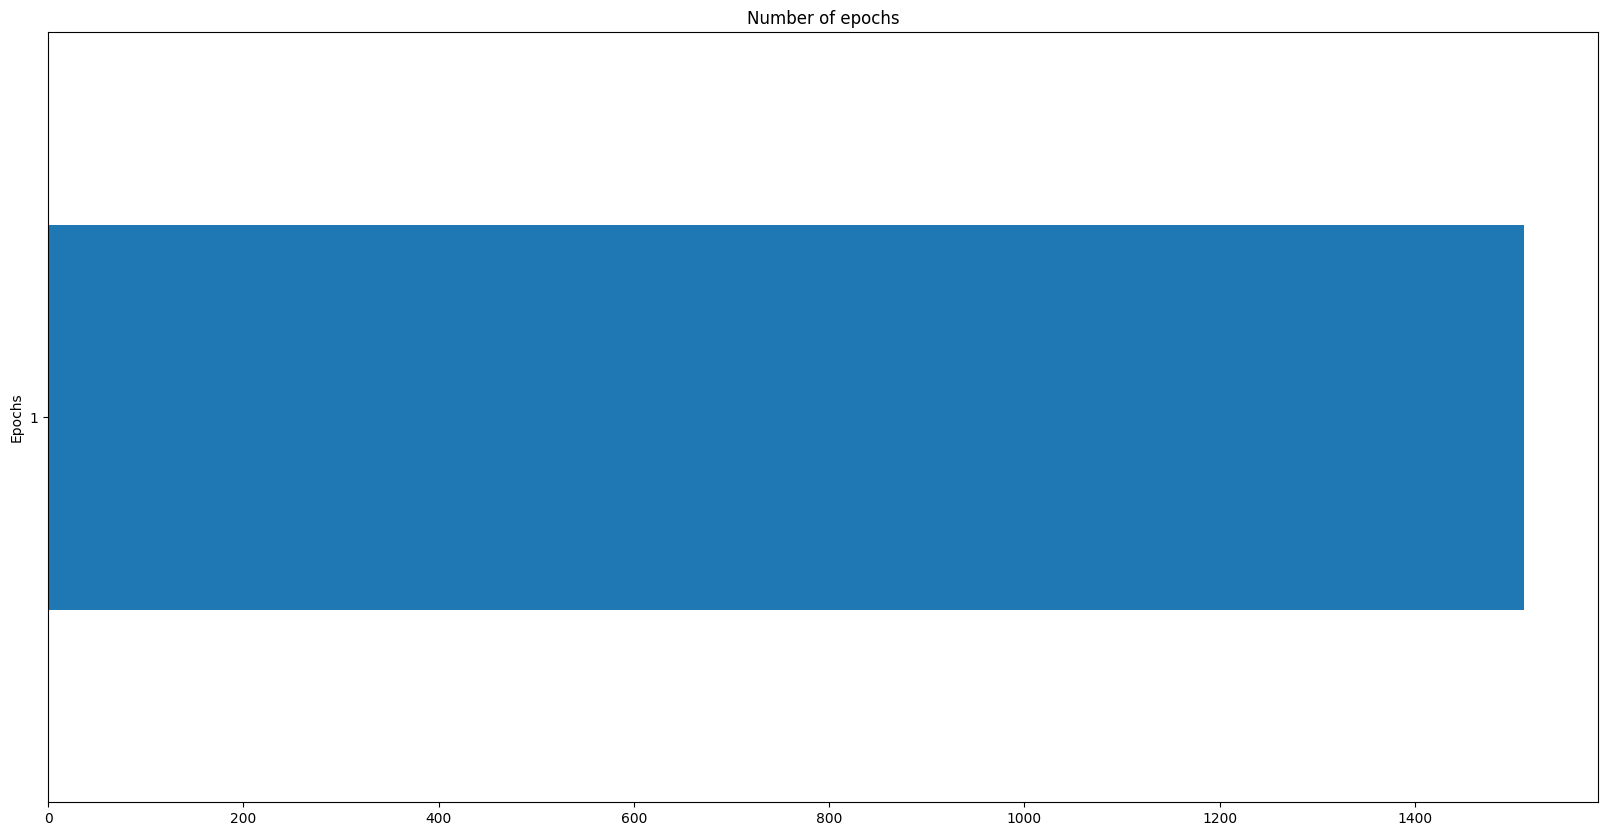

In [15]:

print(len(monitor["id"]), len(monitor["id"].drop_duplicates()))
# print(len(dfs["id"]), len(dfs["id"].drop_duplicates()))
# dfs["id"].value_counts()[:100].plot.barh(figsize=(20, 10))

monitor["id"].value_counts().value_counts().plot.barh(figsize=(20, 10), ylabel="Epochs", title="Number of epochs")
plt.show()

In [16]:
monitor.id

0      52kFfb7kvNHw3Txr2m8HEH
1      55F79J48HrWcBJOYynYev4
2      55ueMwhsrlyXw06fjYZshX
3      56NQoOImgsBImTuq3QcTNc
4      5G7fplSe9hEPcxSCSt8LsY
                ...          
238    6N6oVGA9zBx1rYSJdNm7jd
239    6qAdwuEo0iZJqHHnelNaLy
240    70VjECXPkO7APS1bAj4wEN
241    7IjGG1fEIbM6EjlyfYwqni
242    7nD7b2mbbZuDdwW03rLj3f
Name: id, Length: 1512, dtype: object

In [17]:
monitor[monitor["id"] == "52kFfb7kvNHw3Txr2m8HEH"]

,epoch,step,batch_idx,idx,local_rank,global_rank,node_rank,id,shard_url,data_type,shard_url_base
0,0,0,0,0,7,7,0,52kFfb7kvNHw3Txr2m8HEH,music_artist_sft_frank_sinatra/data/part=00003...,music_vocal,music_artist_sft_frank_sinatra


<Axes: xlabel='step'>

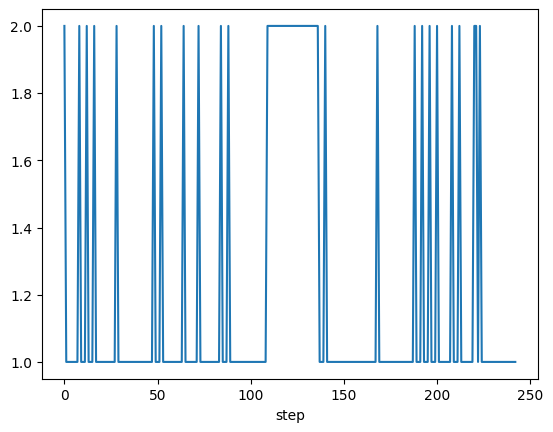

In [18]:
monitor.groupby("step")["shard_url_base"].nunique().plot()

In [21]:
monitor["shard_url_base"].value_counts()

shard_url_base
music_artist_sft_frank_sinatra    1299
music_artist_sft_radiohead         213
Name: count, dtype: int64